In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape

In [8]:
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(28 * 28, activation='sigmoid')) 
model.add(Reshape((28, 28)))
model.compile(optimizer='adam', loss='binary_crossentropy')
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,736 (873.97 KB)

 Trainable params: 223,736 (873.97 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# download the mnist dataset
from tensorflow.keras.datasets import mnist
(x_train, _), (x_test, _) = mnist.load_data()
import numpy as np
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


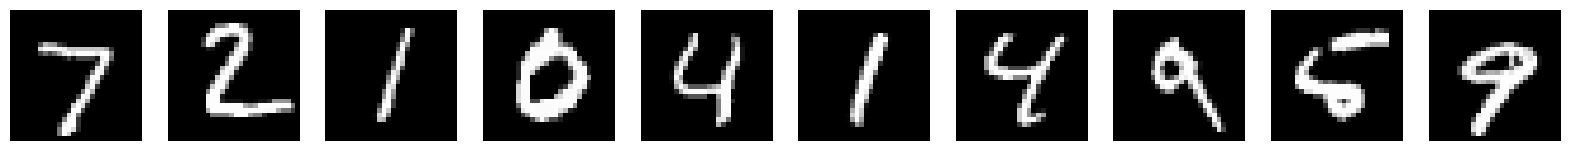

In [10]:
# plot the original images
import matplotlib.pyplot as plt
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis('off')
plt.show()

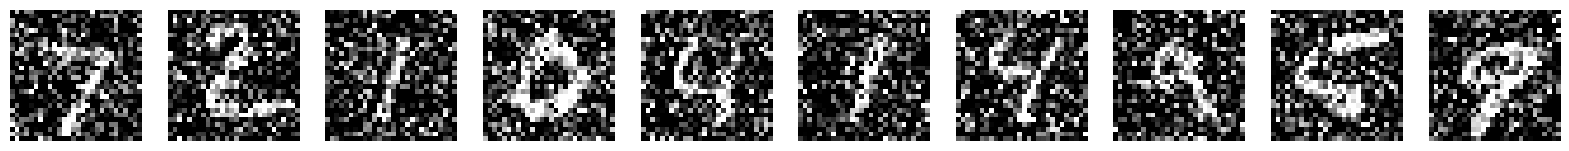

In [14]:
# Add noise to the images
noise_factor = 0.5 
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)
# plot the noisy images
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i], cmap='gray')
    plt.axis('off')
plt.show()

In [15]:
# prepare the data for training for the model declared above
x_train_noisy = x_train_noisy.reshape((len(x_train_noisy), 28, 28))
x_test_noisy = x_test_noisy.reshape((len(x_test_noisy), 28, 28))
model.fit(x_train_noisy, x_train,
          epochs=10,
          batch_size=256,
          shuffle=True,
          validation_data=(x_test_noisy, x_test))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.3625 - val_loss: 0.2436
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.2398 - val_loss: 0.2292
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.2218 - val_loss: 0.2040
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1996 - val_loss: 0.1897
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1881 - val_loss: 0.1816
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1797 - val_loss: 0.1733
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1716 - val_loss: 0.1681
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1675 - val_loss: 0.1647
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1639 - val_loss: 0.1628
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1609 - val_loss: 0.1602


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


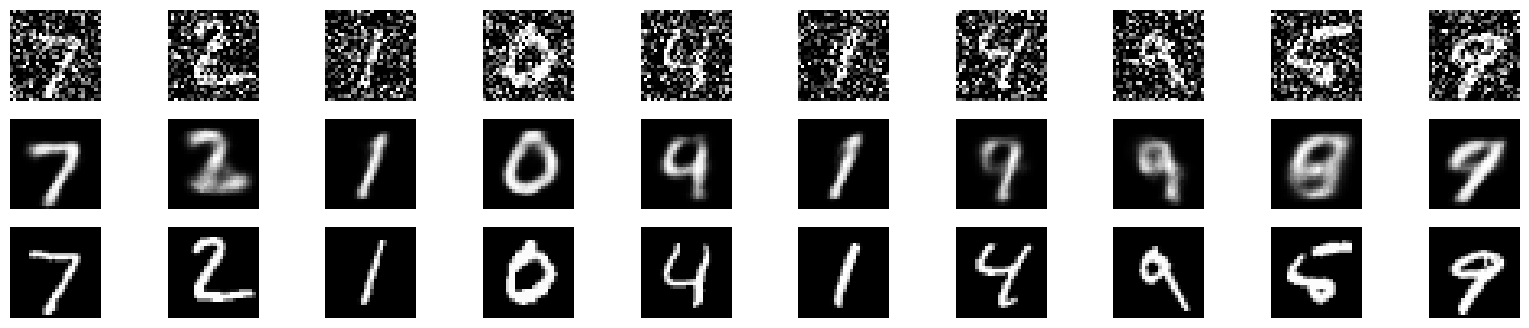

In [16]:
# evaluate the model
decoded_imgs = model.predict(x_test_noisy)
# plot the denoised images along with the noisy images
plt.figure(figsize=(20, 4))
for i in range(n):
    # display noisy
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i], cmap='gray')
    plt.axis('off')
    # display denoised
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i], cmap='gray')
    plt.axis('off')
    # display original
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis('off')
plt.show()